# SAM 3 Image Segmentation with OpenVINO

[SAM 3](https://github.com/facebookresearch/sam3) is Meta's unified vision-language model that supports:
- **Text-prompted segmentation**: Segment objects by describing them in natural language
- **Box-prompted segmentation**: Use bounding boxes as visual prompts (positive/negative)
- **Combined prompts**: Text + negative boxes to exclude regions
- **Point-prompted segmentation** (SAM1 task): Click foreground/background points
- **Video object tracking** (SAM2 task): Track objects across video frames

This notebook demonstrates how to convert SAM 3 models to OpenVINO IR format and run inference using OpenVINO,
aligned with the [official examples on HuggingFace](https://huggingface.co/facebook/sam3).

#### Table of contents:

- [Prerequisites](#Prerequisites)
- [Load PyTorch Model](#Load-PyTorch-Model)
- [PyTorch Baseline Demos](#PyTorch-Baseline-Demos)
  - [Basic Usage](#Basic-Usage)
  - [Text-Only Prompts](#Text-Only-Prompts)
  - [Single Bounding Box Prompt](#Single-Bounding-Box-Prompt)
  - [Multiple Box Prompts (Positive and Negative)](#Multiple-Box-Prompts)
  - [Combined Prompts (Text + Negative Box)](#Combined-Prompts)
  - [SAM3 Tracker](#SAM3-Tracker)
- [Convert Models to OpenVINO](#Convert-Models-to-OpenVINO)
- [OpenVINO Demos](#OpenVINO-Demos)
- [Testing & Verification](#Testing-and-Verification)
- [Performance Comparison](#Performance-Comparison)
- [Interactive Demo](#Interactive-Demo)

⚠️ **EXPERIMENTAL NOTEBOOK**

This notebook demonstrates a model that has not been fully validated with OpenVINO. It may be fully supported and validated in the future.

<img referrerpolicy="no-referrer-when-downgrade" src="https://static.scarf.sh/a.png?x-pxid=5b5a4db0-7875-4bfb-bdbd-01698b5b1a77&file=notebooks\sam3\sam3-segmentation.ipynb" />

### Installation Instructions

This is a self-contained example that relies solely on its own code.

We recommend  running the notebook in a virtual environment. You only need a Jupyter server to start.
For details, please refer to [Installation Guide](https://github.com/openvinotoolkit/openvino_notebooks/blob/latest/README.md#-installation-guide).

## Prerequisites
[back to top ⬆️](#Table-of-contents:)

In [1]:
import platform
import requests
from pathlib import Path

if not Path("notebook_utils.py").exists():
    r = requests.get(url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/notebook_utils.py")
    open("notebook_utils.py", "w").write(r.text)

if not Path("pip_helper.py").exists():
    r = requests.get(
        url="https://raw.githubusercontent.com/openvinotoolkit/openvino_notebooks/latest/utils/pip_helper.py",
    )
    open("pip_helper.py", "w").write(r.text)

from pip_helper import pip_install

pip_install(
    "-q",
    "torch>=2.4",
    "torchvision",
    "openvino>=2024.4",
    "Pillow",
    "matplotlib",
    "--extra-index-url",
    "https://download.pytorch.org/whl/cpu",
)
pip_install(
    "-q",
    "timm>=1.0.17",
    "ftfy==6.1.1",
    "regex",
    "iopath>=0.1.10",
    "scikit-image",
    "scikit-learn",
    "pycocotools",
    "gradio>=4.19",
    "modelscope",
    "einops",
    "decord",
    "huggingface_hub",
    "opencv-python-headless",
    "numpy<2",
    "setuptools<82"
)

# Read more about telemetry collection at https://github.com/openvinotoolkit/openvino_notebooks?tab=readme-ov-file#-telemetry
from notebook_utils import collect_telemetry

collect_telemetry("sam3-segmentation.ipynb")

In [2]:
import subprocess
import sys
import types
from pathlib import Path

# ---------------------------------------------------------------------------
# 1. Clone SAM3 source code
# ---------------------------------------------------------------------------
sam3_root = Path("sam3")
if not sam3_root.exists():
    print("Cloning SAM3 repository...")
    subprocess.run(
        ["git", "clone", "https://github.com/facebookresearch/sam3.git", str(sam3_root)],
        check=True,
    )
    print("SAM3 cloned.")
else:
    print(f"SAM3 source already exists at {sam3_root}")

# ---------------------------------------------------------------------------
# 2. Download SAM3 model weights from ModelScope
# ---------------------------------------------------------------------------
model_dir = Path("sam3_model")
checkpoint = model_dir / "sam3.pt"
if not checkpoint.exists():
    print("Downloading SAM3 weights from ModelScope (facebook/sam3)...")
    try:
        from modelscope import snapshot_download
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "modelscope"], check=True)
        from modelscope import snapshot_download
    snapshot_download("facebook/sam3", local_dir=str(model_dir))
    print(f"Weights downloaded to {model_dir}")
else:
    print(f"SAM3 checkpoint already exists at {checkpoint}")


# ---------------------------------------------------------------------------
# 3. Patch SAM3 source for CPU-only inference (no CUDA).
# ---------------------------------------------------------------------------
def _patch_file(path, replacements):
    p = Path(path)
    text = p.read_text(encoding="utf-8")
    for old, new in replacements:
        text = text.replace(old, new)
    p.write_text(text, encoding="utf-8")


sam3_pkg = sam3_root / "sam3"

_patch_file(
    sam3_pkg / "model" / "position_encoding.py",
    [
        ('device="cuda")', 'device="cpu")'),
    ],
)

_patch_file(
    sam3_pkg / "model" / "decoder.py",
    [
        ('device_type="cuda", enabled=False', 'device_type="cpu", enabled=False'),
        ('feat_size, feat_size, device="cuda"', 'feat_size, feat_size, device="cpu"'),
    ],
)

for rel_path in [
    "model/geometry_encoders.py",
    "model/sam3_tracker_base.py",
    "model/sam3_video_inference.py",
]:
    _patch_file(
        sam3_pkg / rel_path,
        [
            (".pin_memory().to(", ".to("),
        ],
    )

_patch_file(
    sam3_pkg / "model" / "sam3_video_inference.py",
    [
        ('@torch.autocast(device_type="cuda", dtype=torch.bfloat16)', "# autocast disabled on CPU"),
    ],
)

_patch_file(
    sam3_pkg / "model" / "sam3_tracking_predictor.py",
    [
        ('torch.autocast(device_type="cuda", dtype=torch.bfloat16)', 'torch.autocast(device_type="cpu", enabled=False)'),
    ],
)

print("CPU patches applied.")

# ---------------------------------------------------------------------------
# 4. Mock triton (CUDA-only, not needed for CPU/OpenVINO)
#    torch._inductor deeply probes triton submodules, so we mock them all.
# ---------------------------------------------------------------------------
if "triton" not in sys.modules:

    class _ConstExpr:
        pass

    class _DType:
        pass

    class _AttrsDescriptor:
        pass

    def _jit(*a, **kw):
        if len(a) == 1 and callable(a[0]):
            return a[0]

        def w(f):
            return f

        return w

    def _make(name):
        m = types.ModuleType(name)
        m.__path__ = []
        sys.modules[name] = m
        return m

    triton = _make("triton")
    triton.jit = _jit
    triton.cdiv = lambda a, b: (a + b - 1) // b

    tl = _make("triton.language")
    tl.constexpr = _ConstExpr
    tl.dtype = _DType
    triton.language = tl

    tb = _make("triton.backends")
    triton.backends = tb
    tbc = _make("triton.backends.compiler")
    tbc.AttrsDescriptor = _AttrsDescriptor
    tb.compiler = tbc

    tc = _make("triton.compiler")
    triton.compiler = tc
    tcc = _make("triton.compiler.compiler")
    tc.compiler = tcc

    tr = _make("triton.runtime")
    triton.runtime = tr
    _make("triton.runtime.autotuner")
    tr.autotuner = sys.modules["triton.runtime.autotuner"]
    trj = _make("triton.runtime.jit")
    tr.jit = trj

# Add sam3 package to path
sys.path.insert(0, str(sam3_root))
print("Environment ready.")

SAM3 source already exists at sam3
SAM3 checkpoint already exists at sam3_model/sam3.pt
CPU patches applied.
Environment ready.


In [3]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

import openvino as ov

# Suppress unnecessary warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

## Load PyTorch Model
[back to top ⬆️](#Table-of-contents:)

In [4]:
from sam3 import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor
from sam3.visualization_utils import draw_box_on_image, plot_results

bpe_path = str(sam3_root / "sam3" / "assets" / "bpe_simple_vocab_16e6.txt.gz")
checkpoint_path = str(Path("sam3_model") / "sam3.pt")

model = build_sam3_image_model(
    bpe_path=bpe_path,
    device="cpu",
    eval_mode=True,
    checkpoint_path=checkpoint_path,
    load_from_HF=False,
    enable_inst_interactivity=True,
    compile=False,
)
print(f"Model loaded on CPU with {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M parameters")

Model loaded on CPU with 860.1M parameters


Test image size: 1280x720
cat_remote.jpg already downloaded
kitchen.jpg already downloaded


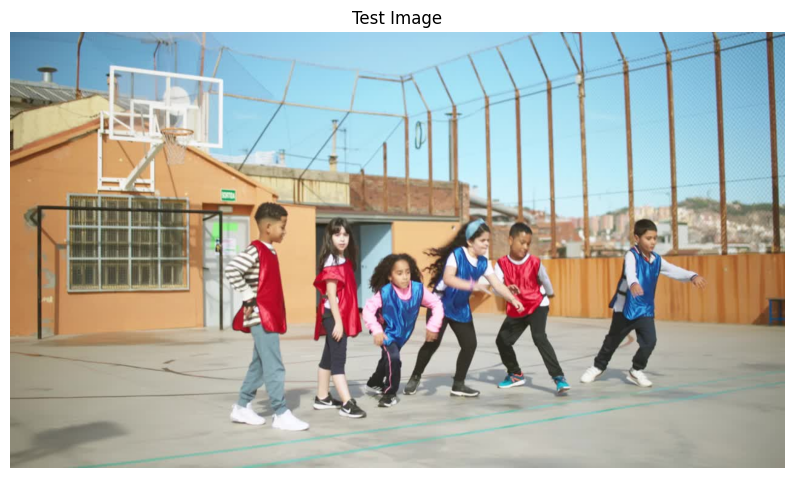

In [5]:
# Load test images
image_path = str(sam3_root / "assets" / "images" / "test_image.jpg")
image = Image.open(image_path)
width, height = image.size
print(f"Test image size: {width}x{height}")

# Download COCO images used in the HuggingFace SAM3 examples
coco_dir = Path("test_images")
coco_dir.mkdir(exist_ok=True)

coco_images = {
    "cat_remote.jpg": "http://images.cocodataset.org/val2017/000000077595.jpg",
    "kitchen.jpg": "http://images.cocodataset.org/val2017/000000136466.jpg",
}

for fname, url in coco_images.items():
    fpath = coco_dir / fname
    if not fpath.exists():
        print(f"Downloading {fname}...")
        r = requests.get(url)
        fpath.write_bytes(r.content)
    else:
        print(f"{fname} already downloaded")

# Also check for truck image (used by SAM3 Tracker)
truck_path = sam3_root / "assets" / "images" / "truck.jpg"
if not truck_path.exists():
    truck_url = "https://huggingface.co/datasets/hf-internal-testing/sam2-fixtures/resolve/main/truck.jpg"
    print("Downloading truck.jpg...")
    r = requests.get(truck_url)
    truck_path.write_bytes(r.content)

plt.figure(figsize=(10, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Test Image")
plt.show()

## PyTorch Baseline Demos
[back to top ⬆️](#Table-of-contents:)

Run the original SAM3 model to establish baselines for comparison with OpenVINO results.
These examples are aligned with the [official HuggingFace model card](https://huggingface.co/facebook/sam3).

### Basic Usage

### Text-Only Prompts

COCO image size: 640x425
found 2 object(s)
Found 2 object(s) with scores: [0.9049283862113953, 0.9179627299308777]


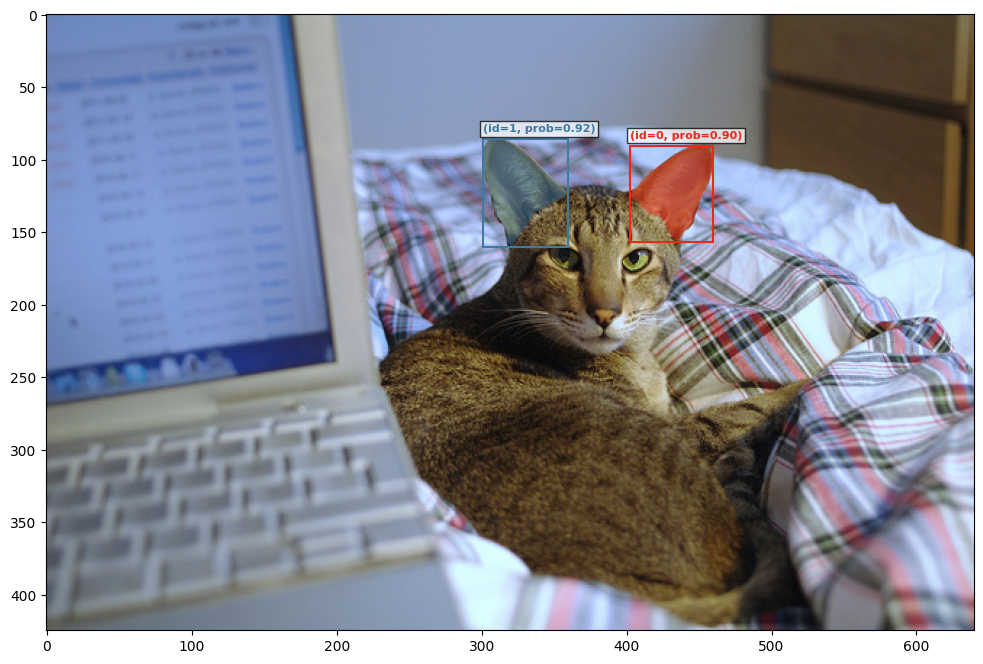

In [6]:
processor = Sam3Processor(model, device="cpu", confidence_threshold=0.5)

# Use COCO image (aligned with HF example)
coco_image = Image.open("test_images/cat_remote.jpg")
coco_w, coco_h = coco_image.size
print(f"COCO image size: {coco_w}x{coco_h}")

inference_state = processor.set_image(coco_image)

processor.reset_all_prompts(inference_state)
inference_state = processor.set_text_prompt(state=inference_state, prompt="ear")

pt_text_masks = inference_state["masks"].clone()
pt_text_scores = inference_state["scores"].clone()

img0 = Image.open("test_images/cat_remote.jpg")
plot_results(img0, inference_state)
print(f"Found {len(pt_text_masks)} object(s) with scores: {pt_text_scores.tolist()}")

### Single Bounding Box Prompt

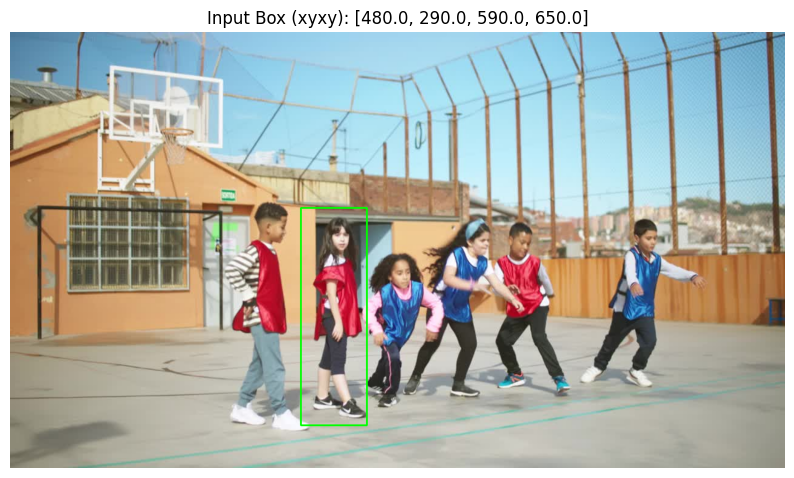

found 6 object(s)


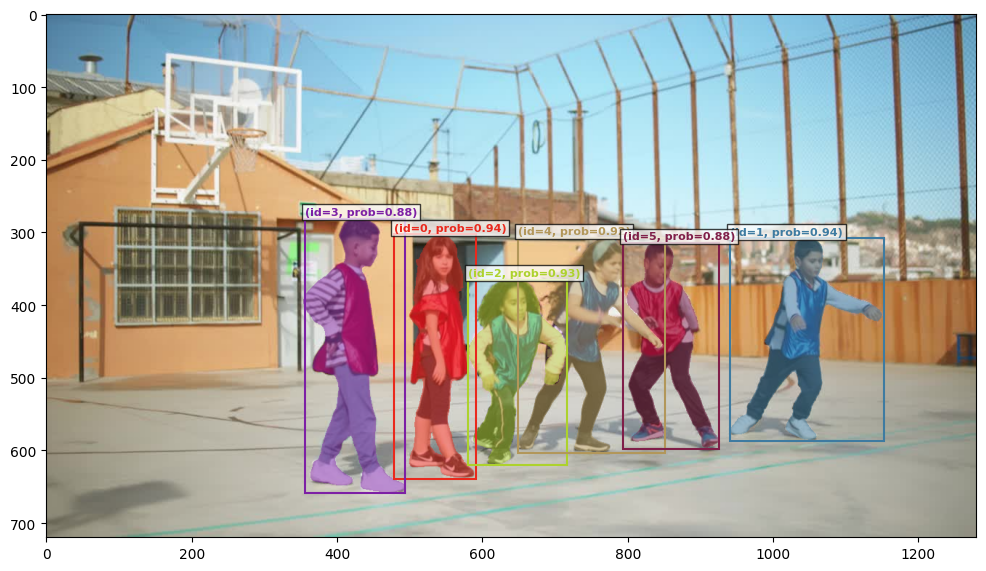

In [7]:
# Box in xyxy pixel format [x1, y1, x2, y2] (matching HF example format)
# Using the test image for this demo
inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)

box_xyxy = [480.0, 290.0, 590.0, 650.0]  # right shoe region
# Convert xyxy to normalized cxcywh for SAM3 native API
x1, y1, x2, y2 = box_xyxy
cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
bw, bh = x2 - x1, y2 - y1
norm_box_cxcywh = [cx / width, cy / height, bw / width, bh / height]

inference_state = processor.add_geometric_prompt(state=inference_state, box=norm_box_cxcywh, label=True)

pt_box_masks = inference_state["masks"].clone()

# Visualize input box
img0 = Image.open(image_path)
box_xywh = [box_xyxy[0], box_xyxy[1], box_xyxy[2] - box_xyxy[0], box_xyxy[3] - box_xyxy[1]]
image_with_box = draw_box_on_image(img0, box_xywh)
plt.figure(figsize=(10, 8))
plt.imshow(image_with_box)
plt.axis("off")
plt.title(f"Input Box (xyxy): {box_xyxy}")
plt.show()

img0 = Image.open(image_path)
plot_results(img0, inference_state)

### Multiple Box Prompts (Positive and Negative)

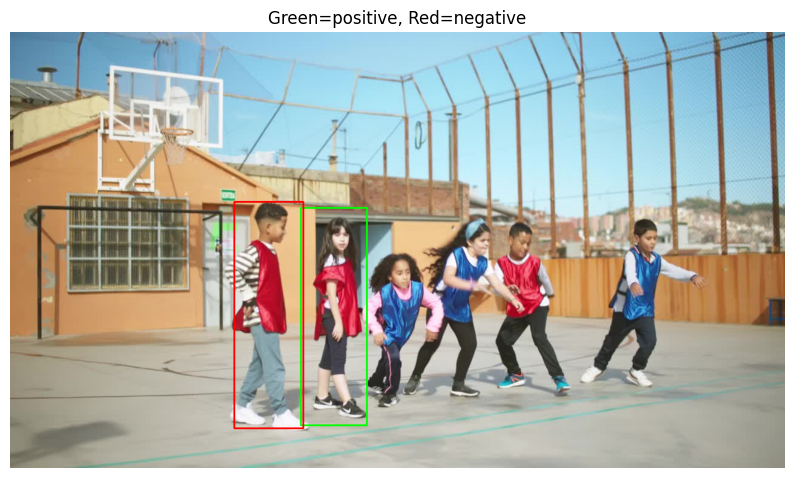

found 5 object(s)


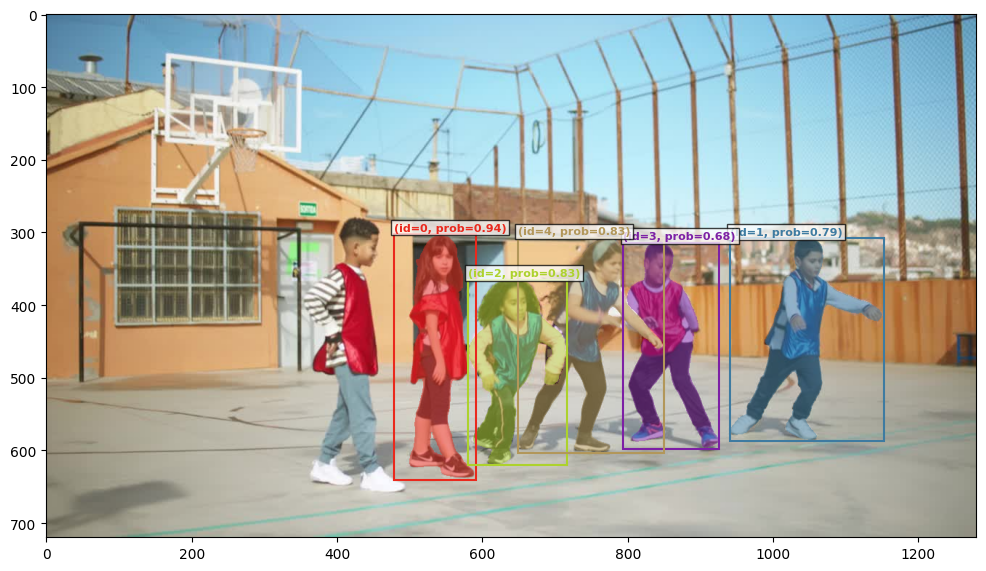

In [8]:
# Two boxes in xyxy format: positive (right shoe) + negative (left shoe)
inference_state = processor.set_image(image)
processor.reset_all_prompts(inference_state)

boxes_xyxy = [[480.0, 290.0, 590.0, 650.0], [370.0, 280.0, 485.0, 655.0]]
box_labels = [True, False]  # True=positive, False=negative

for box_xyxy_i, label in zip(boxes_xyxy, box_labels):
    x1, y1, x2, y2 = box_xyxy_i
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    bw, bh = x2 - x1, y2 - y1
    norm_cxcywh = [cx / width, cy / height, bw / width, bh / height]
    inference_state = processor.add_geometric_prompt(state=inference_state, box=norm_cxcywh, label=label)

pt_multibox_masks = inference_state["masks"].clone()

# Visualize boxes
img0 = Image.open(image_path)
for i, box_xyxy_i in enumerate(boxes_xyxy):
    x1, y1, x2, y2 = box_xyxy_i
    color = (0, 255, 0) if box_labels[i] else (255, 0, 0)
    img0 = draw_box_on_image(img0, [x1, y1, x2 - x1, y2 - y1], color)
plt.figure(figsize=(10, 8))
plt.imshow(img0)
plt.axis("off")
plt.title("Green=positive, Red=negative")
plt.show()

img0 = Image.open(image_path)
plot_results(img0, inference_state)

### Combined Prompts (Text + Negative Box)

Segment objects matching a text prompt while excluding specific regions using negative bounding boxes.
This example uses the kitchen image: find "handle" but exclude the oven handle region.

Kitchen image size: 332x500
Text-only 'handle': found 5 objects
found 5 object(s)
Text + negative box: found 3 objects


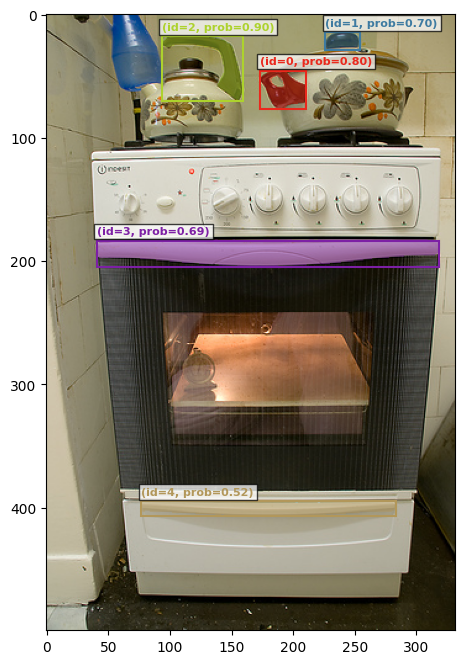

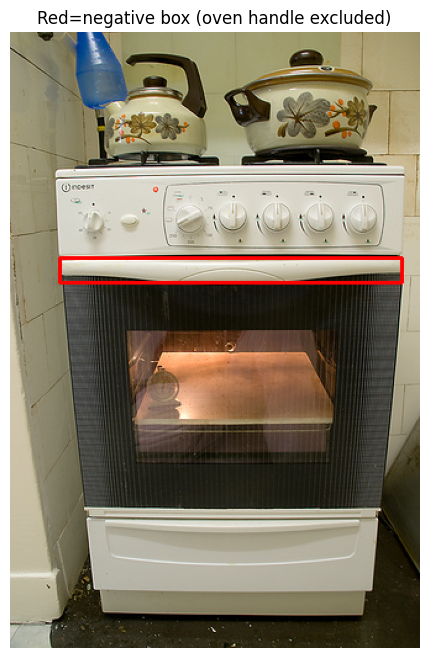

found 3 object(s)


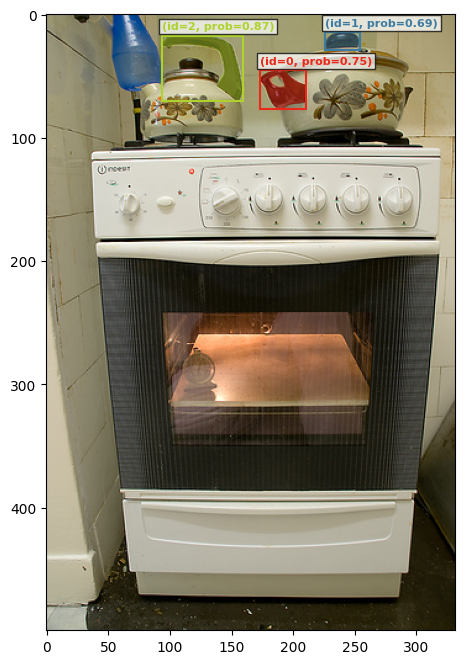

In [9]:
# Combined Prompts: text "handle" + negative box to exclude oven handle region
kitchen_image = Image.open("test_images/kitchen.jpg")
kitchen_w, kitchen_h = kitchen_image.size
print(f"Kitchen image size: {kitchen_w}x{kitchen_h}")

inference_state_kitchen = processor.set_image(kitchen_image)

# Step 1: Set text prompt "handle"
processor.reset_all_prompts(inference_state_kitchen)
inference_state_kitchen = processor.set_text_prompt(state=inference_state_kitchen, prompt="handle")

print(f"Text-only 'handle': found {len(inference_state_kitchen['masks'])} objects")
img0 = Image.open("test_images/kitchen.jpg")
plot_results(img0, inference_state_kitchen)

# Step 2: Add negative box to exclude oven handle region
oven_handle_box_xyxy = [40.0, 183.0, 318.0, 204.0]
x1, y1, x2, y2 = oven_handle_box_xyxy
cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
bw, bh = x2 - x1, y2 - y1
neg_box_cxcywh = [cx / kitchen_w, cy / kitchen_h, bw / kitchen_w, bh / kitchen_h]

inference_state_kitchen = processor.add_geometric_prompt(state=inference_state_kitchen, box=neg_box_cxcywh, label=False)  # False = negative

pt_combined_masks = inference_state_kitchen["masks"].clone()
pt_combined_scores = inference_state_kitchen["scores"].clone()

print(f"Text + negative box: found {len(pt_combined_masks)} objects")

# Visualize
img0 = Image.open("test_images/kitchen.jpg")
box_xywh = [x1, y1, x2 - x1, y2 - y1]
img0 = draw_box_on_image(img0, box_xywh, (255, 0, 0))
plt.figure(figsize=(10, 8))
plt.imshow(img0)
plt.axis("off")
plt.title("Red=negative box (oven handle excluded)")
plt.show()

img0 = Image.open("test_images/kitchen.jpg")
plot_results(img0, inference_state_kitchen)

### SAM3 Tracker

SAM3 includes a tracker model (SAM2-style) for point/box-based interactive segmentation.
This is equivalent to the SAM3 Tracker example on HuggingFace.

Truck image size: 1800x1200


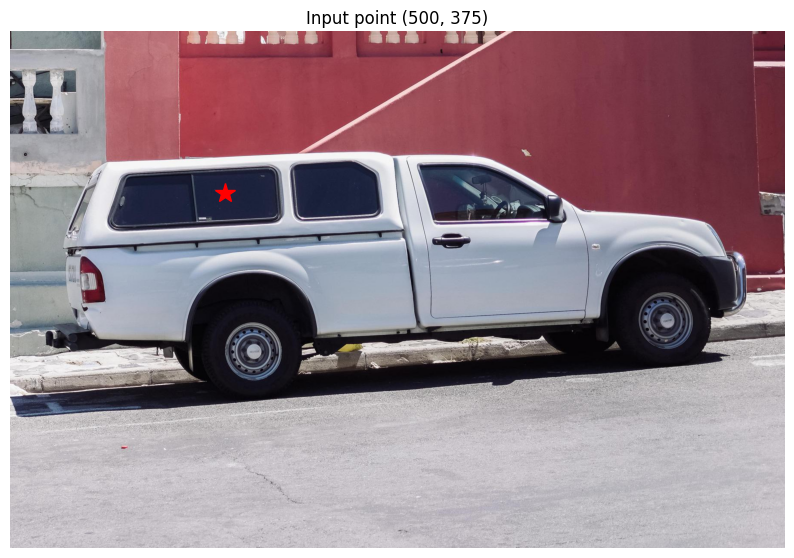

Generated 3 masks, best score: 0.9073


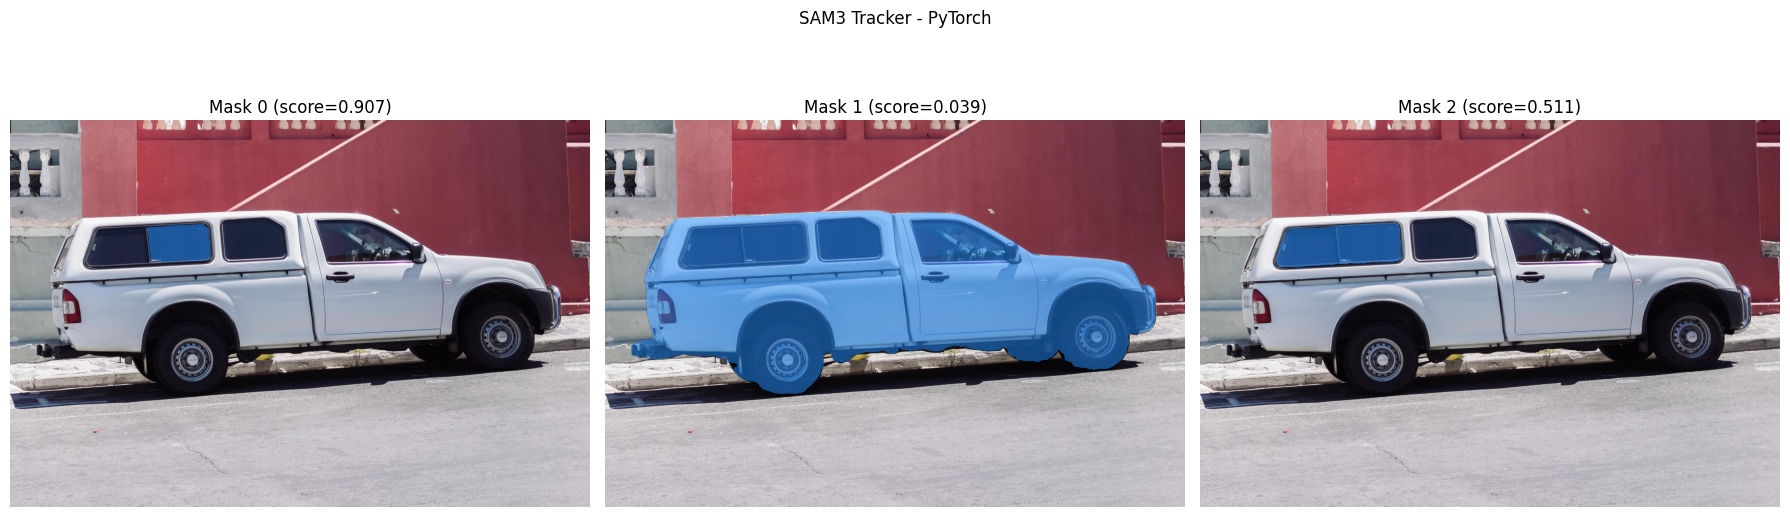

In [10]:
# SAM3 Tracker: single point click on truck image (matching HF example)
truck_image_path = str(sam3_root / "assets" / "images" / "truck.jpg")
truck_image = Image.open(truck_image_path)
truck_w, truck_h = truck_image.size
print(f"Truck image size: {truck_w}x{truck_h}")

plt.figure(figsize=(10, 8))
plt.imshow(truck_image)
plt.plot(500, 375, "r*", markersize=15)
plt.axis("off")
plt.title("Input point (500, 375)")
plt.show()

# Use the SAM3 interactive predictor (SAM2-style tracker for single image)
# The tracker shares the main model's backbone — set it before calling set_image
if model.inst_interactive_predictor is not None:
    tracker_predictor = model.inst_interactive_predictor
    tracker_predictor.model.backbone = model.backbone
    tracker_predictor.set_image(truck_image)

    input_point = np.array([[500, 375]])
    input_label = np.array([1])  # 1 = foreground

    pt_tracker_masks, pt_tracker_scores, pt_tracker_logits = tracker_predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=True,
    )

    best_idx = np.argmax(pt_tracker_scores)
    print(f"Generated {pt_tracker_masks.shape[0]} masks, best score: {pt_tracker_scores[best_idx]:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i in range(min(3, pt_tracker_masks.shape[0])):
        axes[i].imshow(truck_image)
        mask = pt_tracker_masks[i]
        colored = np.zeros((*mask.shape, 4))
        colored[mask > 0.5] = [0.12, 0.56, 1.0, 0.5]
        axes[i].imshow(colored)
        axes[i].set_title(f"Mask {i} (score={pt_tracker_scores[i]:.3f})")
        axes[i].axis("off")
    plt.suptitle("SAM3 Tracker - PyTorch")
    plt.tight_layout()
    plt.show()
else:
    print("Tracker not available (inst_interactivity not enabled)")

## Convert Models to OpenVINO
[back to top ⬆️](#Table-of-contents:)

We decompose the SAM3 model into separate sub-models for OpenVINO conversion.
Each sub-model is wrapped in a dedicated class that produces traceable forward passes.

The model is decomposed into multiple sub-models for efficient conversion:
1. **Image Encoder** — ViT backbone with FPN neck
2. **Text Encoder** — Text transformer for language understanding
3. **Transformer Encoder** — Multi-level feature fusion with text cross-attention
4. **Transformer Decoder** — Object query decoding with box refinement
5. **Scoring** — Dot-product scoring + final box prediction
6. **Segmentation Head** — Pixel decoder + mask prediction
7. **Geometry Projections** — Box embedding projections (Linear/Conv2d/Embedding, no control flow)
8. **Geometry Cross-Attention** — CLS token + cross-attention encoder (no control flow)
9. **SAM1 Feature Prep** — conv_s0/s1 + no_mem_embed for SAM1 task features
10. **SAM2 Prompt Encoder** — Point/box prompt encoding (for SAM1/Tracker task)
11. **SAM2 Mask Decoder** — Mask prediction from prompts (for SAM1/Tracker task)

The geometry encoder is split into two OV models to eliminate control flow:
only weighted torch ops (projections, embeddings, cross-attention layers) are converted to OV IR.
Non-weighted ops (roi_align, sinusoidal position encoding, LayerNorm) run in Python.

In [11]:
from ov_sam3_helper import (
    patch_vit_rope,
    Sam3ImageEncoderModel,
    Sam3TextEncoderModel,
    Sam3TransformerEncoderModel,
    Sam3TransformerDecoderModel,
    Sam3ScoringModel,
    Sam3SegmentationHeadModel,
    Sam3SAM2PromptEncoderModel,
    Sam3SAM2MaskDecoderModel,
    Sam3SAM1FeaturePrepModel,
    Sam3GeoProjectionsForOV,
    Sam3GeoCrossAttnForOV,
    convert_and_save_model,
    save_geo_encoder_config,
)

ov_model_dir = Path("ov_models")
ov_model_dir.mkdir(exist_ok=True)

### Image Encoder

The image encoder uses a ViT backbone with Rotary Position Encoding (RoPE).
We must replace the complex tensor-based RoPE with matrix multiplication before conversion.

In [12]:
# Patch RoPE to use matrix multiplication (OpenVINO doesn't support complex tensors)
patch_vit_rope(model.backbone.vision_backbone.trunk)

image_encoder_wrapper = Sam3ImageEncoderModel(
    neck=model.backbone.vision_backbone,
    scalp=model.backbone.scalp,
)

ov_image_encoder_path = ov_model_dir / "image_encoder.xml"
ov_image_encoder_model = convert_and_save_model(
    wrapper_model=image_encoder_wrapper,
    example_input=torch.zeros(1, 3, 1008, 1008),
    save_path=str(ov_image_encoder_path),
    model_name="Image Encoder",
)

  Converting Image Encoder...
  Saved Image Encoder to /home/ethan/intel/openvino_notebooks/notebooks/sam3/ov_models/image_encoder.xml


### Text Encoder

In [13]:
text_encoder_wrapper = Sam3TextEncoderModel(
    text_encoder=model.backbone.language_backbone,
)

ov_text_encoder_path = ov_model_dir / "text_encoder.xml"
ov_text_encoder_model = convert_and_save_model(
    wrapper_model=text_encoder_wrapper,
    example_input=torch.zeros(1, 32, dtype=torch.long),
    save_path=str(ov_text_encoder_path),
    model_name="Text Encoder",
)

  Converting Text Encoder...
  Saved Text Encoder to /home/ethan/intel/openvino_notebooks/notebooks/sam3/ov_models/text_encoder.xml


### Transformer Encoder

The transformer encoder fuses image features with text prompt embeddings through cross-attention.

In [14]:
encoder_wrapper = Sam3TransformerEncoderModel(
    encoder=model.transformer.encoder,
    feat_h=72,
    feat_w=72,
)

# Dummy inputs: seq-first (HW, B, C) where H=W=72
seq_len = 72 * 72  # 5184
dummy_img_feat = torch.randn(seq_len, 1, 256)
dummy_img_pos = torch.randn(seq_len, 1, 256)
# Prompt: (seq_len, B, C) - text prompt features
dummy_prompt = torch.randn(10, 1, 256)
dummy_prompt_mask = torch.zeros(1, 10, dtype=torch.bool)

ov_encoder_path = ov_model_dir / "transformer_encoder.xml"
ov_encoder_model = convert_and_save_model(
    wrapper_model=encoder_wrapper,
    example_input=(dummy_img_feat, dummy_img_pos, dummy_prompt, dummy_prompt_mask),
    save_path=str(ov_encoder_path),
    model_name="Transformer Encoder",
)

  Converting Transformer Encoder...
  Saved Transformer Encoder to /home/ethan/intel/openvino_notebooks/notebooks/sam3/ov_models/transformer_encoder.xml


### Transformer Decoder

The decoder handles object query decoding with cross-attention to encoder memory and text prompts.

### Scoring

The scoring model computes dot-product scores between object queries and text prompts,
and performs final box refinement via bbox_embed + decoder_norm.

In [15]:
# --- Transformer Decoder ---
decoder_wrapper = Sam3TransformerDecoderModel(
    decoder=model.transformer.decoder,
)

seq_len = 72 * 72  # 5184
dummy_memory = torch.randn(seq_len, 1, 256)
dummy_pos_embed = torch.randn(seq_len, 1, 256)
dummy_memory_mask = torch.zeros(1)
dummy_level_start = torch.tensor([0], dtype=torch.long)
dummy_spatial = torch.tensor([[72, 72]], dtype=torch.long)
dummy_valid_ratios = torch.ones(1, 1, 2)
dummy_prompt_dec = torch.randn(10, 1, 256)
dummy_prompt_mask_dec = torch.zeros(1, 10, dtype=torch.bool)

# Force re-conversion for the new split models
for name in ["decoder", "scoring"]:
    for ext in [".xml", ".bin"]:
        p = ov_model_dir / f"{name}{ext}"
        if p.exists():
            p.unlink()

ov_decoder_path = ov_model_dir / "decoder.xml"
ov_decoder_model = convert_and_save_model(
    wrapper_model=decoder_wrapper,
    example_input=(
        dummy_memory,
        dummy_pos_embed,
        dummy_memory_mask,
        dummy_level_start,
        dummy_spatial,
        dummy_valid_ratios,
        dummy_prompt_dec,
        dummy_prompt_mask_dec,
    ),
    save_path=str(ov_decoder_path),
    model_name="Transformer Decoder",
)

# --- Scoring ---
num_queries = model.transformer.decoder.num_queries
num_layers = len(model.transformer.decoder.layers)

scoring_wrapper = Sam3ScoringModel(
    dot_prod_scoring=model.dot_prod_scoring,
    bbox_embed=model.transformer.decoder.bbox_embed,
    decoder_norm=model.transformer.decoder.norm,
)

# Scoring inputs (batch-first, as output by decoder after transpose)
dummy_hs_bf = torch.randn(num_layers, 1, num_queries, 256)
dummy_ref_bf = torch.randn(num_layers + 1, 1, num_queries, 4)
dummy_prompt_sc = torch.randn(10, 1, 256)
dummy_mask_sc = torch.zeros(1, 10, dtype=torch.bool)

ov_scoring_path = ov_model_dir / "scoring.xml"
ov_scoring_model = convert_and_save_model(
    wrapper_model=scoring_wrapper,
    example_input=(dummy_hs_bf, dummy_ref_bf, dummy_prompt_sc, dummy_mask_sc),
    save_path=str(ov_scoring_path),
    model_name="Scoring",
)

  Converting Transformer Decoder...
  Saved Transformer Decoder to /home/ethan/intel/openvino_notebooks/notebooks/sam3/ov_models/decoder.xml
  Converting Scoring...
  Saved Scoring to /home/ethan/intel/openvino_notebooks/notebooks/sam3/ov_models/scoring.xml


### Segmentation Head

The segmentation head includes a pixel decoder (FPN upsampling), instance segmentation head, and mask predictor.

In [ ]:
num_queries = model.transformer.decoder.num_queries
num_layers = len(model.transformer.decoder.layers)

seg_wrapper = Sam3SegmentationHeadModel(
    seg_head=model.segmentation_head,
)

# FPN features at 3 resolution levels (after scalp=1)
seq_len = 72 * 72  # 5184
dummy_fpn0 = torch.randn(1, 256, 288, 288)
dummy_fpn1 = torch.randn(1, 256, 144, 144)
dummy_fpn2 = torch.randn(1, 256, 72, 72)
dummy_obj_queries = torch.randn(1, num_queries, 256)
dummy_enc_states = torch.randn(seq_len, 1, 256)
dummy_prompt_seg = torch.randn(10, 1, 256)
dummy_mask_seg = torch.zeros(1, 10, dtype=torch.bool)

ov_seg_path = ov_model_dir / "segmentation_head.xml"
ov_seg_model = convert_and_save_model(
    wrapper_model=seg_wrapper,
    example_input=(
        dummy_fpn0,
        dummy_fpn1,
        dummy_fpn2,
        dummy_obj_queries,
        dummy_enc_states,
        dummy_prompt_seg,
        dummy_mask_seg,
    ),
    save_path=str(ov_seg_path),
    model_name="Segmentation Head",
)

  Converting Segmentation Head...


### SAM2-Style Prompt Encoder (for SAM1 Task)

Used for point/box prompting with the interactive predictor.

In [ ]:
if model.inst_interactive_predictor is not None:
    tracker_model = model.inst_interactive_predictor.model

    prompt_enc_wrapper = Sam3SAM2PromptEncoderModel(
        prompt_encoder=tracker_model.sam_prompt_encoder,
        image_size=tracker_model.image_size,
    )

    dummy_coords = torch.zeros(1, 3, 2)  # (B, N_points, 2)
    dummy_labels = torch.ones(1, 3, dtype=torch.int32)  # (B, N_points)
    dummy_has_box = torch.tensor(0)

    ov_prompt_enc_path = ov_model_dir / "sam2_prompt_encoder.xml"
    ov_prompt_enc_model = convert_and_save_model(
        wrapper_model=prompt_enc_wrapper,
        example_input=(dummy_coords, dummy_labels, dummy_has_box),
        save_path=str(ov_prompt_enc_path),
        model_name="SAM2 Prompt Encoder",
    )
else:
    print("Skipping SAM2 Prompt Encoder (inst_interactivity not enabled)")

### SAM2-Style Mask Decoder (for SAM1 Task)

In [ ]:
if model.inst_interactive_predictor is not None:
    mask_dec_wrapper = Sam3SAM2MaskDecoderModel(
        model=tracker_model,
        multimask_output=True,
    )

    # SAM2 mask decoder inputs
    dummy_img_embed = torch.randn(1, 256, 72, 72)
    dummy_hires_0 = torch.randn(1, 32, 288, 288)
    dummy_hires_1 = torch.randn(1, 64, 144, 144)
    dummy_sparse = torch.randn(1, 3, 256)
    dummy_dense = torch.randn(1, 256, 72, 72)

    ov_mask_dec_path = ov_model_dir / "sam2_mask_decoder.xml"
    ov_mask_dec_model = convert_and_save_model(
        wrapper_model=mask_dec_wrapper,
        example_input=(
            dummy_img_embed,
            dummy_hires_0,
            dummy_hires_1,
            dummy_sparse,
            dummy_dense,
        ),
        save_path=str(ov_mask_dec_path),
        model_name="SAM2 Mask Decoder",
    )
else:
    print("Skipping SAM2 Mask Decoder (inst_interactivity not enabled)")


### Geometry Encoder (Split) + SAM1 Feature Prep

The geometry encoder handles box prompts (positive/negative bounding boxes).
To avoid control flow issues in OV conversion, it is split into two OV models:
- **Geometry Projections**: `boxes_direct_project` (Linear), `boxes_pos_enc_project` (Linear), `boxes_pool_project` (Conv2d), `label_embed` (Embedding) — all weighted ops merged, zero control flow
- **Geometry Cross-Attention**: `cls_embed`, `final_proj`, `norm`, 3-layer cross-attention, `encode_norm` — zero control flow

Non-weighted ops run in Python: sinusoidal position encoding, `img_pre_norm` (LayerNorm with extracted weights), `roi_align` (torchvision), box coordinate transforms.

The SAM1 Feature Prep model (`conv_s0`, `conv_s1`, `no_mem_embed`) is also converted using `convert_and_save_model`.

In [ ]:
import copy, json

# ============================================================================
# Convert Geometry Encoder (split into 2 control-flow-free OV models)
# ============================================================================
# Split Sam3GeometryEncoderForOV into:
#   1. geo_projections: Linear projections + Embedding (no control flow, no roi_align)
#   2. geo_cross_attn: CLS + final_proj + cross-attention layers (no control flow)
# Non-weighted ops (roi_align, sinusoidal pos_enc, LayerNorm) run in Python.

geo_encoder = copy.deepcopy(model.geometry_encoder).cpu()

# Save config + constant arrays for Python glue (pos_enc params, img_pre_norm weights)
save_geo_encoder_config(geo_encoder, str(ov_model_dir))

# --- Geometry Projections OV model ---
geo_proj_wrapper = Sam3GeoProjectionsForOV(geo_encoder)
geo_proj_wrapper.eval()

C = geo_encoder.d_model  # 256
d_pos = geo_encoder.pos_enc.num_pos_feats * 2 + 2  # 258
roi_size = geo_encoder.roi_size
max_boxes = 10

ov_geo_proj_model = convert_and_save_model(
    wrapper_model=geo_proj_wrapper,
    example_input=(
        torch.zeros(max_boxes, 1, 4),                       # boxes (N,1,4)
        torch.zeros(max_boxes, 1, d_pos),                   # pos_features (N,1,258)
        torch.zeros(max_boxes, C, roi_size, roi_size),      # roi_features (N,C,7,7)
        torch.ones(max_boxes, 1, dtype=torch.long),         # labels (N,1)
    ),
    save_path=str(ov_model_dir / "geo_projections.xml"),
    model_name="Geometry Projections",
)

# --- Geometry Cross-Attention OV model ---
geo_cross_wrapper = Sam3GeoCrossAttnForOV(geo_encoder)
geo_cross_wrapper.eval()

HW = 72 * 72  # 5184
ov_geo_cross_model = convert_and_save_model(
    wrapper_model=geo_cross_wrapper,
    example_input=(
        torch.randn(max_boxes, 1, C),                       # box_embed (N,1,C)
        torch.ones(1, max_boxes, dtype=torch.bool),          # box_mask (1,N)
        torch.randn(HW, 1, C),                              # img_feat (HW,1,C)
        torch.randn(HW, 1, C),                              # img_pos (HW,1,C)
    ),
    save_path=str(ov_model_dir / "geo_cross_attn.xml"),
    model_name="Geometry Cross-Attention",
)

# ============================================================================
# Convert SAM1 Feature Prep (conv_s0/s1 + no_mem_embed)
# ============================================================================
if model.inst_interactive_predictor is not None:
    tracker_model = model.inst_interactive_predictor.model

    # Save scalar config (no weights — those go into OV IR)
    sam1_config = {
        "bb_feat_sizes": model.inst_interactive_predictor._bb_feat_sizes,
        "mask_threshold": float(model.inst_interactive_predictor.mask_threshold),
        "image_size": int(tracker_model.image_size),
        "num_feature_levels": int(tracker_model.num_feature_levels),
    }
    with open(ov_model_dir / "sam1_config.json", "w") as f:
        json.dump(sam1_config, f)
    print(f"  Saved SAM1 config to {ov_model_dir / 'sam1_config.json'}")

    sam1_wrapper = Sam3SAM1FeaturePrepModel(
        conv_s0=copy.deepcopy(tracker_model.sam_mask_decoder.conv_s0).cpu(),
        conv_s1=copy.deepcopy(tracker_model.sam_mask_decoder.conv_s1).cpu(),
        no_mem_embed=tracker_model.no_mem_embed.detach().cpu().clone(),
    )
    sam1_wrapper.eval()

    bb = model.inst_interactive_predictor._bb_feat_sizes
    c0_in = tracker_model.sam_mask_decoder.conv_s0.in_channels
    c1_in = tracker_model.sam_mask_decoder.conv_s1.in_channels

    ov_sam1_prep_model = convert_and_save_model(
        wrapper_model=sam1_wrapper,
        example_input=(
            torch.randn(1, c0_in, bb[0][0], bb[0][1]),
            torch.randn(1, c1_in, bb[1][0], bb[1][1]),
        ),
        save_path=str(ov_model_dir / "sam1_feature_prep.xml"),
        model_name="SAM1 Feature Prep",
    )
else:
    print("  [skip] No SAM1 predictor — skipping SAM1 Feature Prep")

## OpenVINO Demos
[back to top ⬆️](#Table-of-contents:)

Now run the same examples using OpenVINO inference pipeline.

In [ ]:
from notebook_utils import device_widget

device = device_widget(default="CPU", exclude=["NPU"])
device

In [ ]:
core = ov.Core()

# Compile all detector models
ov_image_encoder = core.compile_model(ov_model_dir / "image_encoder.xml", device.value)
ov_text_encoder = core.compile_model(ov_model_dir / "text_encoder.xml", device.value)
ov_transformer_encoder = core.compile_model(ov_model_dir / "transformer_encoder.xml", device.value)
ov_decoder = core.compile_model(ov_model_dir / "decoder.xml", device.value)
ov_scoring = core.compile_model(ov_model_dir / "scoring.xml", device.value)
ov_seg_head = core.compile_model(ov_model_dir / "segmentation_head.xml", device.value)

# Compile split geometry encoder (2 models, no control flow)
ov_geo_projections = core.compile_model(ov_model_dir / "geo_projections.xml", device.value)
print("Geometry Projections compiled")
ov_geo_cross_attn = core.compile_model(ov_model_dir / "geo_cross_attn.xml", device.value)
print("Geometry Cross-Attention compiled")

# Compile SAM1 feature prep (conv_s0/s1 + no_mem_embed — OV IR)
ov_sam1_feature_prep = None
if (ov_model_dir / "sam1_feature_prep.xml").exists():
    ov_sam1_feature_prep = core.compile_model(ov_model_dir / "sam1_feature_prep.xml", device.value)
    print("SAM1 Feature Prep compiled")

# Compile SAM2 models for SAM1-style point/box prompting (Tracker)
ov_prompt_encoder = None
ov_mask_decoder = None
if (ov_model_dir / "sam2_prompt_encoder.xml").exists():
    ov_prompt_encoder = core.compile_model(ov_model_dir / "sam2_prompt_encoder.xml", device.value)
    print("SAM2 Prompt Encoder compiled")
if (ov_model_dir / "sam2_mask_decoder.xml").exists():
    ov_mask_decoder = core.compile_model(ov_model_dir / "sam2_mask_decoder.xml", device.value)
    print("SAM2 Mask Decoder compiled")

print("All models compiled successfully!")

In [ ]:
from ov_sam3_helper import OVSam3Processor
from sam3.model.tokenizer_ve import SimpleTokenizer

# Tokenizer: load from BPE vocab file (no model weights)
bpe_path = str(sam3_root / "sam3" / "assets" / "bpe_simple_vocab_16e6.txt.gz")
tokenizer = SimpleTokenizer(bpe_path=bpe_path)

# Build OV pipeline — fully independent of original PyTorch model.
# ALL weighted operations run as compiled OV models (no torch weight ops).
# Geometry encoder is split into 2 control-flow-free OV models:
#   - geo_projections: Linear/Conv2d/Embedding projections
#   - geo_cross_attn: CLS + final_proj + cross-attention layers
# Non-weighted ops (roi_align, sinusoidal pos_enc, LayerNorm) run in Python.
ov_processor = OVSam3Processor(
    ov_image_encoder=ov_image_encoder,
    ov_text_encoder=ov_text_encoder,
    ov_transformer_encoder=ov_transformer_encoder,
    ov_decoder=ov_decoder,
    ov_scoring=ov_scoring,
    ov_seg_head=ov_seg_head,
    tokenizer=tokenizer,
    ov_prompt_encoder=ov_prompt_encoder,
    ov_mask_decoder=ov_mask_decoder,
    ov_geo_projections=ov_geo_projections,
    ov_geo_cross_attn=ov_geo_cross_attn,
    geo_config_path=str(ov_model_dir / "geo_config.json"),
    ov_sam1_feature_prep=ov_sam1_feature_prep,
    sam1_config_path=str(ov_model_dir / "sam1_config.json"),
    confidence_threshold=0.5,
    max_boxes=10,
)
print("OVSam3Processor ready (SAM1 task:", "enabled" if ov_processor._sam1_ready else "disabled", ")")

### Text-Only Prompts (OpenVINO)

In [ ]:
# Text-Only Prompts: "ear" on COCO image (matching HF example)
ov_state = ov_processor.set_image(coco_image)

ov_processor.reset_all_prompts(ov_state)
ov_state = ov_processor.set_text_prompt(prompt="ear", state=ov_state)

ov_text_masks = ov_state["masks"].clone()
ov_text_scores = ov_state["scores"].clone()

img0 = Image.open("test_images/cat_remote.jpg")
plot_results(img0, ov_state)
print(f"Found {len(ov_text_masks)} object(s) with scores: {ov_text_scores.tolist()}")

### Single Bounding Box Prompt (OpenVINO)

In [ ]:
# Single box prompt (xyxy format, matching HF example)
ov_state = ov_processor.set_image(image)
ov_processor.reset_all_prompts(ov_state)

box_xyxy = [480.0, 290.0, 590.0, 650.0]
x1, y1, x2, y2 = box_xyxy
cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
bw, bh = x2 - x1, y2 - y1
norm_box_cxcywh = [cx / width, cy / height, bw / width, bh / height]

ov_state = ov_processor.add_geometric_prompt(state=ov_state, box=norm_box_cxcywh, label=True)

ov_box_masks = ov_state["masks"].clone()

img0 = Image.open(image_path)
box_xywh = [x1, y1, x2 - x1, y2 - y1]
image_with_box = draw_box_on_image(img0, box_xywh)
plt.figure(figsize=(10, 8))
plt.imshow(image_with_box)
plt.axis("off")
plt.title(f"Input Box (xyxy): {box_xyxy}")
plt.show()

img0 = Image.open(image_path)
plot_results(img0, ov_state)

### Multiple Box Prompts (OpenVINO)

In [ ]:
# Multiple boxes: positive + negative (xyxy format)
ov_state = ov_processor.set_image(image)
ov_processor.reset_all_prompts(ov_state)

boxes_xyxy = [[480.0, 290.0, 590.0, 650.0], [370.0, 280.0, 485.0, 655.0]]
box_labels = [True, False]

for box_xyxy_i, label in zip(boxes_xyxy, box_labels):
    x1, y1, x2, y2 = box_xyxy_i
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    bw, bh = x2 - x1, y2 - y1
    norm_cxcywh = [cx / width, cy / height, bw / width, bh / height]
    ov_state = ov_processor.add_geometric_prompt(state=ov_state, box=norm_cxcywh, label=label)

ov_multibox_masks = ov_state["masks"].clone()

# Visualize
img0 = Image.open(image_path)
for i, box_xyxy_i in enumerate(boxes_xyxy):
    x1, y1, x2, y2 = box_xyxy_i
    color = (0, 255, 0) if box_labels[i] else (255, 0, 0)
    img0 = draw_box_on_image(img0, [x1, y1, x2 - x1, y2 - y1], color)
plt.figure(figsize=(10, 8))
plt.imshow(img0)
plt.axis("off")
plt.title("Green=positive, Red=negative")
plt.show()

img0 = Image.open(image_path)
plot_results(img0, ov_state)

### Combined Prompts (Text + Negative Box) (OpenVINO)

In [ ]:
# Combined Prompts (OV): text "handle" + negative box to exclude oven handle
ov_state_kitchen = ov_processor.set_image(kitchen_image)

# Step 1: Set text prompt
ov_processor.reset_all_prompts(ov_state_kitchen)
ov_state_kitchen = ov_processor.set_text_prompt(prompt="handle", state=ov_state_kitchen)
print(f"Text-only 'handle': found {len(ov_state_kitchen['masks'])} objects")

# Step 2: Add negative box
oven_handle_box_xyxy = [40.0, 183.0, 318.0, 204.0]
x1, y1, x2, y2 = oven_handle_box_xyxy
cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
bw, bh = x2 - x1, y2 - y1
neg_box_cxcywh = [cx / kitchen_w, cy / kitchen_h, bw / kitchen_w, bh / kitchen_h]

ov_state_kitchen = ov_processor.add_geometric_prompt(state=ov_state_kitchen, box=neg_box_cxcywh, label=False)

ov_combined_masks = ov_state_kitchen["masks"].clone()
ov_combined_scores = ov_state_kitchen["scores"].clone()

print(f"Text + negative box: found {len(ov_combined_masks)} objects")

# Visualize
img0 = Image.open("test_images/kitchen.jpg")
box_xywh = [x1, y1, x2 - x1, y2 - y1]
img0 = draw_box_on_image(img0, box_xywh, (255, 0, 0))
plt.figure(figsize=(10, 8))
plt.imshow(img0)
plt.axis("off")
plt.title("Red=negative box (oven handle excluded)")
plt.show()

img0 = Image.open("test_images/kitchen.jpg")
plot_results(img0, ov_state_kitchen)

### SAM3 Tracker (OpenVINO)

In [ ]:
# SAM3 Tracker (OV): single point click on truck image
ov_truck_state = ov_processor.set_image(truck_image)

input_point = np.array([[500, 375]])
input_label = np.array([1])

ov_tracker_masks, ov_tracker_scores, ov_tracker_logits = ov_processor.predict_inst(
    ov_truck_state,
    point_coords=input_point,
    point_labels=input_label,
    multimask_output=True,
)

best_idx = np.argmax(ov_tracker_scores.flatten())
print(f"Generated {ov_tracker_masks.shape[0]} masks, best score: {ov_tracker_scores.flatten()[best_idx]:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i in range(min(3, ov_tracker_masks.shape[0])):
    axes[i].imshow(truck_image)
    mask = ov_tracker_masks[i]
    colored = np.zeros((*mask.shape[-2:], 4))
    mask_2d = mask.squeeze()
    colored[mask_2d > 0.5] = [0.12, 0.56, 1.0, 0.5]
    axes[i].imshow(colored)
    score = ov_tracker_scores.flatten()[i]
    axes[i].set_title(f"Mask {i} (score={score:.3f})")
    axes[i].axis("off")
plt.suptitle("SAM3 Tracker - OpenVINO")
plt.tight_layout()
plt.show()

## Testing and Verification
[back to top ⬆️](#Table-of-contents:)

Compare PyTorch and OpenVINO outputs to verify conversion correctness.

In [ ]:
from ov_sam3_helper import compare_masks, cosine_similarity

results = []

# Test 1: Text prompt masks comparison
if pt_text_masks.shape == ov_text_masks.shape:
    iou = compare_masks(pt_text_masks, ov_text_masks, title="Text Prompt: PyTorch vs OpenVINO")
    results.append(("Text prompt 'ear'", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Text prompt 'ear'", f"Shape mismatch: PT={pt_text_masks.shape} vs OV={ov_text_masks.shape}", "FAIL"))

# Test 2: Box prompt masks comparison
if pt_box_masks.shape == ov_box_masks.shape:
    iou = compare_masks(pt_box_masks, ov_box_masks, title="Box Prompt: PyTorch vs OpenVINO")
    results.append(("Single box prompt", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Single box prompt", f"Shape mismatch: PT={pt_box_masks.shape} vs OV={ov_box_masks.shape}", "FAIL"))

# Test 3: Multi-box masks comparison
if pt_multibox_masks.shape == ov_multibox_masks.shape:
    iou = compare_masks(pt_multibox_masks, ov_multibox_masks, title="Multi-box: PyTorch vs OpenVINO")
    results.append(("Multi-box prompt", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Multi-box prompt", f"Shape mismatch: PT={pt_multibox_masks.shape} vs OV={ov_multibox_masks.shape}", "FAIL"))

# Test 4: Combined prompts comparison
if pt_combined_masks.shape == ov_combined_masks.shape:
    iou = compare_masks(pt_combined_masks, ov_combined_masks, title="Combined Prompts: PyTorch vs OpenVINO")
    results.append(("Combined prompts", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
else:
    results.append(("Combined prompts", f"Shape mismatch: PT={pt_combined_masks.shape} vs OV={ov_combined_masks.shape}", "FAIL"))

# Test 5: SAM3 Tracker comparison
if model.inst_interactive_predictor is not None:
    pt_best = pt_tracker_masks[np.argmax(pt_tracker_scores)]
    ov_best = ov_tracker_masks[np.argmax(ov_tracker_scores.flatten())]
    pt_t = torch.from_numpy(pt_best).float()
    ov_t = torch.from_numpy(ov_best.squeeze()).float()
    if pt_t.shape == ov_t.shape:
        iou = compare_masks(pt_t, ov_t, title="SAM3 Tracker: PyTorch vs OpenVINO")
        results.append(("SAM3 Tracker", f"IoU={iou:.4f}", "PASS" if iou > 0.90 else "FAIL"))
    else:
        results.append(("SAM3 Tracker", f"Shape mismatch: PT={pt_t.shape} vs OV={ov_t.shape}", "FAIL"))
else:
    results.append(("SAM3 Tracker", "Skipped (no tracker)", "SKIP"))

## Performance Comparison
[back to top ⬆️](#Table-of-contents:)

Compare inference latency between PyTorch (CPU) and OpenVINO.

In [ ]:
import time

n_runs = 3

ov_full_times = []
for _ in range(n_runs):
    t0 = time.perf_counter()
    s = ov_processor.set_image(image)
    ov_processor.reset_all_prompts(s)
    s = ov_processor.set_text_prompt(prompt="shoe", state=s)
    ov_full_times.append(time.perf_counter() - t0)

pt_full_times = []
pt_proc = Sam3Processor(model, device="cpu", confidence_threshold=0.5)
for _ in range(n_runs):
    t0 = time.perf_counter()
    s = pt_proc.set_image(image)
    pt_proc.reset_all_prompts(s)
    s = pt_proc.set_text_prompt(state=s, prompt="shoe")
    pt_full_times.append(time.perf_counter() - t0)

ov_full_avg = np.mean(ov_full_times)
pt_full_avg = np.mean(pt_full_times)

print(f"\nFull Pipeline Latency (text prompt, {n_runs} runs average):")
print(f"  PyTorch (CPU):  {pt_full_avg:.3f}s")
print(f"  OpenVINO ({device.value}): {ov_full_avg:.3f}s")
print(f"  Speedup: {pt_full_avg / ov_full_avg:.2f}x")

## Interactive Demo
[back to top ⬆️](#Table-of-contents:)

Use the interactive Gradio demo below to try SAM3 with your own images. You can:
- Upload an image and enter a text prompt to segment objects
- Draw bounding boxes to specify regions of interest
- Click points for SAM1-style foreground/background prompting

In [ ]:
import gradio as gr
import numpy as np
import torch
from PIL import Image, ImageDraw

# Example images bundled with the repo / downloaded earlier
_EXAMPLES_TEXT = [
    ["test_images/cat_remote.jpg", "cat", 0.5],
    ["test_images/kitchen.jpg", "handle", 0.5],
]
_EXAMPLES_POINT = [
    ["test_images/cat_remote.jpg"],
    ["sam3/assets/images/truck.jpg"],
]
_EXAMPLES_BOX = [
    ["sam3/assets/images/test_image.jpg", "480, 290, 590, 650"],
    ["sam3/assets/images/truck.jpg", "200, 300, 650, 470"],
]


def segment_text(image, text_prompt, confidence):
    """Segment objects by text prompt."""
    if image is None or not text_prompt.strip():
        return None
    pil_image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    state = ov_processor.set_image(pil_image)
    ov_processor.confidence_threshold = confidence
    ov_processor.reset_all_prompts(state)
    state = ov_processor.set_text_prompt(prompt=text_prompt, state=state)
    masks = state.get("masks")
    scores = state.get("scores")
    if masks is None or len(masks) == 0:
        return image
    return _overlay_masks(image, masks, scores)


def segment_point(image, point_type, evt: gr.SelectData):
    """Segment by clicking a point on the image.

    Foreground (label=1): segment the clicked object.
    Background (label=0): In SAM, a single background point alone is
    ambiguous, so we use foreground detection and then INVERT the mask
    to show "everything except this object".
    """
    if image is None:
        return image
    x, y = evt.index
    pil_image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    state = ov_processor.set_image(pil_image)

    # Always detect with foreground label first
    masks, scores, _ = ov_processor.predict_inst(
        state,
        point_coords=np.array([[x, y]]),
        point_labels=np.array([1]),
        multimask_output=True,
    )
    best_idx = np.argmax(scores.flatten())
    mask = masks[best_idx]

    # Background mode: invert the mask to show everything EXCEPT the object
    is_background = point_type == "Background"
    if is_background:
        mask = ~mask

    result = _overlay_single_mask(image, mask)

    # Draw the clicked point on the result
    pil_result = Image.fromarray(result) if isinstance(result, np.ndarray) else result.copy()
    draw = ImageDraw.Draw(pil_result)
    r = 6
    color = (0, 255, 0) if not is_background else (255, 0, 0)
    draw.ellipse([x - r, y - r, x + r, y + r], fill=color, outline="white", width=2)
    score = scores.flatten()[best_idx]
    label = "BG" if is_background else "FG"
    draw.text((x + r + 4, y - r), f"{label} {score:.3f}", fill="white")
    return np.array(pil_result)


def segment_box(image, box_input):
    """Segment by bounding box [x0, y0, x1, y1]."""
    if image is None or not box_input.strip():
        return image
    try:
        coords = [float(x.strip()) for x in box_input.split(",")]
        assert len(coords) == 4
    except Exception:
        return image
    pil_image = Image.fromarray(image) if isinstance(image, np.ndarray) else image
    state = ov_processor.set_image(pil_image)
    input_box = np.array(coords)

    # Use multimask_output=False so predict_inst picks best mask by score
    masks, scores, _ = ov_processor.predict_inst(
        state,
        box=input_box,
        multimask_output=False,
    )

    result = _overlay_single_mask(image, masks[0])

    # Draw the input box and score on the result
    pil_result = Image.fromarray(result) if isinstance(result, np.ndarray) else result.copy()
    draw = ImageDraw.Draw(pil_result)
    x0, y0, x1, y1 = coords
    draw.rectangle([x0, y0, x1, y1], outline=(0, 255, 0), width=3)
    score = scores.flatten()[0]
    label_text = f"score: {score:.4f}"
    # Draw label background
    tw = len(label_text) * 8
    th = 20
    label_y = max(y0 - th, 0)
    draw.rectangle([x0, label_y, x0 + tw, label_y + th], fill=(0, 255, 0))
    draw.text((x0 + 2, label_y + 2), label_text, fill="black")
    return np.array(pil_result)


def _overlay_masks(image, masks, scores=None):
    """Overlay multiple masks on image with different colors."""
    import matplotlib.cm as cm

    img = np.array(image).copy() if not isinstance(image, np.ndarray) else image.copy()
    colors = cm.tab10(np.linspace(0, 1, 10))[:, :3]
    for i, mask in enumerate(masks):
        m = mask.cpu().numpy().squeeze() if isinstance(mask, torch.Tensor) else np.squeeze(mask)
        color = (colors[i % len(colors)] * 255).astype(np.uint8)
        img[m > 0.5] = img[m > 0.5] * 0.5 + color * 0.5
    return img


def _overlay_single_mask(image, mask, color=(30, 144, 255)):
    """Overlay a single mask on image."""
    img = np.array(image).copy() if not isinstance(image, np.ndarray) else image.copy()
    m = mask.squeeze()
    if isinstance(m, torch.Tensor):
        m = m.cpu().numpy()
    color = np.array(color, dtype=np.uint8)
    img[m > 0.5] = (img[m > 0.5] * 0.5 + color * 0.5).astype(np.uint8)
    return img


with gr.Blocks(title="SAM3 OpenVINO Demo") as demo:
    gr.Markdown("# SAM 3 Segmentation with OpenVINO")
    with gr.Tabs():
        with gr.TabItem("Text Prompt"):
            with gr.Row():
                with gr.Column():
                    text_image = gr.Image(label="Input Image", type="numpy")
                    text_input = gr.Textbox(label="Text Prompt", placeholder="e.g. shoe, person, car...")
                    confidence = gr.Slider(0.1, 0.9, value=0.5, step=0.05, label="Confidence Threshold")
                    text_btn = gr.Button("Segment", variant="primary")
                with gr.Column():
                    text_output = gr.Image(label="Result")
            text_btn.click(segment_text, [text_image, text_input, confidence], text_output)
            gr.Examples(
                examples=_EXAMPLES_TEXT,
                inputs=[text_image, text_input, confidence],
                outputs=text_output,
                fn=segment_text,
                cache_examples=False,
                label="Examples",
            )

        with gr.TabItem("Point Prompt (SAM1)"):
            gr.Markdown(
                "**Foreground** (green dot): segment the object you click on.  \n"
                "**Background** (red dot): segment everything EXCEPT the object you click on "
                "(inverted foreground mask)."
            )
            with gr.Row():
                with gr.Column():
                    point_image = gr.Image(label="Click on image to segment", type="numpy")
                    point_type = gr.Radio(["Foreground", "Background"], value="Foreground", label="Point Type")
                with gr.Column():
                    point_output = gr.Image(label="Result")
            point_image.select(segment_point, [point_image, point_type], point_output)
            gr.Examples(
                examples=_EXAMPLES_POINT,
                inputs=[point_image],
                label="Examples (click image after loading)",
            )

        with gr.TabItem("Box Prompt (SAM1)"):
            with gr.Row():
                with gr.Column():
                    box_image = gr.Image(label="Input Image", type="numpy")
                    box_input = gr.Textbox(label="Box coordinates (x0, y0, x1, y1)", placeholder="480, 290, 590, 650")
                    box_btn = gr.Button("Segment", variant="primary")
                with gr.Column():
                    box_output = gr.Image(label="Result")
            box_btn.click(segment_box, [box_image, box_input], box_output)
            gr.Examples(
                examples=_EXAMPLES_BOX,
                inputs=[box_image, box_input],
                outputs=box_output,
                fn=segment_box,
                cache_examples=False,
                label="Examples",
            )

# Skip Gradio launch during headless execution (e.g. nbconvert)
import os as _os

if "NBCONVERT" not in _os.environ and "JUPYTER_EXECUTE" not in _os.environ:
    try:
        demo.launch(debug=True)
    except Exception:
        demo.launch(debug=True, share=True)
else:
    print("Skipping Gradio demo in headless mode")

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
